<a href="https://colab.research.google.com/github/Vin1233/SE/blob/main/MW_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('fruits1.csv')

In [3]:
df.shape

(150, 4)

In [4]:
df.head()

,Order Id,Apples,Orange,Banana
0,16723,9.0,NaN,6.0
1,16724,12.0,12.0,6.0
2,16725,9.0,NaN,NaN
3,16726,12.0,NaN,24.0
4,16727,30.0,8.0,10.0


In [5]:
df.tail()

,Order Id,Apples,Orange,Banana
145,16868,24.0,12.0,6.0
146,16869,8.0,8.0,12.0
147,16870,5.0,30.0,30.0
148,16871,24.0,NaN,10.0
149,16872,5.0,30.0,10.0


In [6]:
df.columns

Index(['Order Id', 'Apples', 'Orange', 'Banana'], dtype='object')

In [7]:
for column in df.columns:
    print(column)

Order Id
Apples
Orange
Banana


In [9]:
d={
    'Apples':'Apples',
    'Orange':'Oranges',
    'Banana':'Bananas'
}
d

{'Apples': 'Apples', 'Orange': 'Oranges', 'Banana': 'Bananas'}

In [10]:
df.rename(columns = d, inplace = True)

In [11]:
df.columns

Index(['Order Id', 'Apples', 'Oranges', 'Bananas'], dtype='object')

# **Data** **Cleaning**

In [12]:
df.dtypes

,0
Order Id,int64
Apples,float64
Oranges,float64
Bananas,float64


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Order Id  150 non-null    int64  
 1   Apples    134 non-null    float64
 2   Oranges   134 non-null    float64
 3   Bananas   129 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 4.8 KB


In [14]:
df.isnull()

,Order Id,Apples,Oranges,Bananas
0,False,False,True,False
1,False,False,False,False
2,False,False,True,True
3,False,False,True,False
4,False,False,False,False
...,...,...,...,...
145,False,False,False,False
146,False,False,False,False
147,False,False,False,False
148,False,False,True,False


In [15]:
len(df.columns)

4

In [16]:
df.shape


(150, 4)

In [17]:
df.isnull().sum()

,0
Order Id,0
Apples,16
Oranges,16
Bananas,21


Checking missing values count on each column, applying sorting

In [18]:
df.isnull().sum().sort_values()

,0
Order Id,0
Apples,16
Oranges,16
Bananas,21


In [19]:
df.isnull().sum().sort_values(ascending = False)

,0
Bananas,21
Apples,16
Oranges,16
Order Id,0


In [22]:
df.describe()

,Order Id,Apples,Oranges,Bananas
count,150.000000,134.000000,134.000000,129.000000
mean,16797.500000,13.492537,14.186567,12.651163
std,43.445368,8.745135,8.870131,8.084177
min,16723.000000,5.000000,5.000000,5.000000
25%,16760.250000,6.000000,8.000000,8.000000
50%,16797.500000,10.000000,10.000000,10.000000
75%,16834.750000,24.000000,24.000000,12.000000
max,16872.000000,30.000000,30.000000,30.000000


Dropping missing values

In [23]:
df_new = df.dropna()

In [24]:
df_new.isnull().sum()

,0
Order Id,0
Apples,0
Oranges,0
Bananas,0


In [25]:
df_new.describe().round(2)

,Order Id,Apples,Oranges,Bananas
count,105.00,105.00,105.00,105.00
mean,16800.83,13.47,14.24,11.96
std,43.80,8.77,8.98,7.59
min,16724.00,5.00,5.00,5.00
25%,16763.00,6.00,8.00,6.00
50%,16804.00,10.00,10.00,10.00
75%,16838.00,24.00,24.00,12.00
max,16872.00,30.00,30.00,30.00


In [28]:
df_new['Total_Quantity'] = df_new['Apples'] + df_new['Bananas']+ df_new['Oranges']
df_new.head()

/tmp/ipykernel_6067/396019600.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['Total_Quantity'] = df_new['Apples'] + df_new['Bananas']+ df_new['Oranges']


,Order Id,Apples,Oranges,Bananas,amount_spent,Total_Quantity
1,16724,12.0,12.0,6.0,30.0,30.0
4,16727,30.0,8.0,10.0,48.0,48.0
5,16728,6.0,6.0,12.0,24.0,24.0
6,16729,12.0,24.0,9.0,45.0,45.0
7,16730,24.0,6.0,8.0,38.0,38.0


In [29]:
df_new.head()

,Order Id,Apples,Oranges,Bananas,amount_spent,Total_Quantity
1,16724,12.0,12.0,6.0,30.0,30.0
4,16727,30.0,8.0,10.0,48.0,48.0
5,16728,6.0,6.0,12.0,24.0,24.0
6,16729,12.0,24.0,9.0,45.0,45.0
7,16730,24.0,6.0,8.0,38.0,38.0


Exploratory Data Analysis (EDA)

In [34]:
o=df_new.groupby(by = ['Total_Quantity']).count()

In [35]:
o.sort_values(by = 'Total_Quantity', ascending = False).head()

,Order Id,Apples,Oranges,Bananas,amount_spent
Total_Quantity,,,,,
84.0,1,1,1,1,1
78.0,2,2,2,2,2
69.0,1,1,1,1,1
66.0,1,1,1,1,1
65.0,2,2,2,2,2


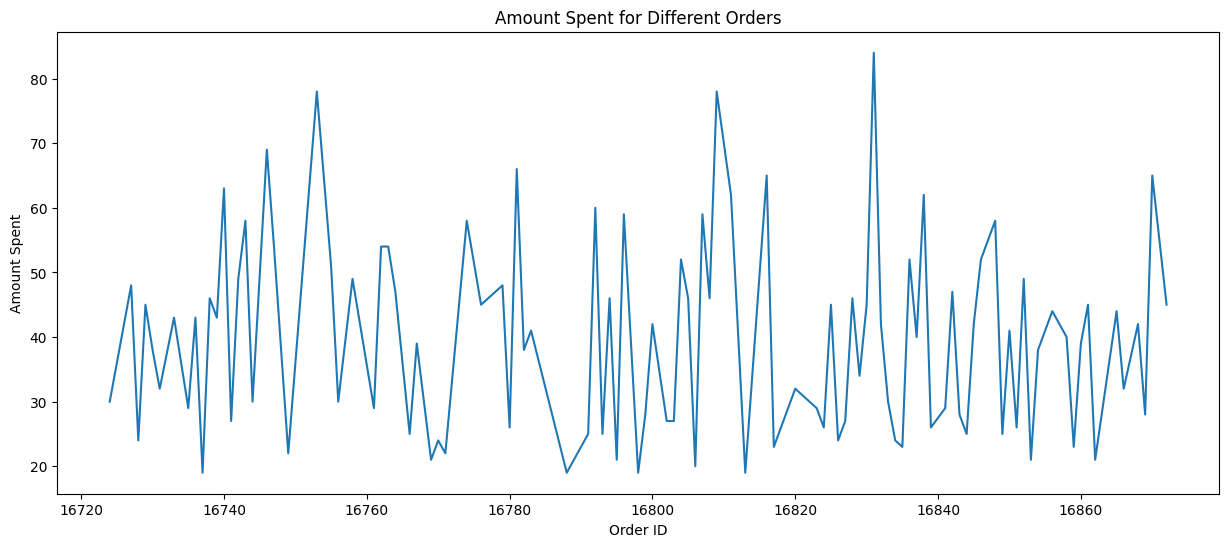

In [39]:
plt.subplots(figsize=(15,6))

plt.plot(df_new['Order Id'], df_new['amount_spent'])

plt.xlabel('Order ID')
plt.ylabel('Amount Spent')
plt.title('Amount Spent for Different Orders')

plt.show()


In [40]:
apple_price = 10
orange_price = 5
banana_price = 3

df_new['money_spent'] = (
    df_new['Apples'] * apple_price +
    df_new['Oranges'] * orange_price +
    df_new['Bananas'] * banana_price
)

/tmp/ipykernel_6067/1618121715.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['money_spent'] = (


In [41]:
df_new.head()

,Order Id,Apples,Oranges,Bananas,amount_spent,Total_Quantity,money_spent
1,16724,12.0,12.0,6.0,30.0,30.0,198.0
4,16727,30.0,8.0,10.0,48.0,48.0,370.0
5,16728,6.0,6.0,12.0,24.0,24.0,126.0
6,16729,12.0,24.0,9.0,45.0,45.0,267.0
7,16730,24.0,6.0,8.0,38.0,38.0,294.0


In [43]:
df_new = df_new.drop('amount_spent', axis=1)

In [44]:
df_new.head()

,Order Id,Apples,Oranges,Bananas,Total_Quantity,money_spent
1,16724,12.0,12.0,6.0,30.0,198.0
4,16727,30.0,8.0,10.0,48.0,370.0
5,16728,6.0,6.0,12.0,24.0,126.0
6,16729,12.0,24.0,9.0,45.0,267.0
7,16730,24.0,6.0,8.0,38.0,294.0


In [46]:
df_new.sort_values(by='money_spent', ascending=False).head()

,Order Id,Apples,Oranges,Bananas,Total_Quantity,money_spent
108,16831,30.0,24.0,30.0,84.0,510.0
93,16816,30.0,30.0,5.0,65.0,465.0
86,16809,24.0,30.0,24.0,78.0,462.0
30,16753,24.0,24.0,30.0,78.0,450.0
115,16838,30.0,24.0,8.0,62.0,444.0


In [48]:
df_new.sort_values(by='money_spent', ascending=False).head(10)

,Order Id,Apples,Oranges,Bananas,Total_Quantity,money_spent
108,16831,30.0,24.0,30.0,84.0,510.0
93,16816,30.0,30.0,5.0,65.0,465.0
86,16809,24.0,30.0,24.0,78.0,462.0
30,16753,24.0,24.0,30.0,78.0,450.0
115,16838,30.0,24.0,8.0,62.0,444.0
88,16811,24.0,30.0,8.0,62.0,414.0
69,16792,24.0,30.0,6.0,60.0,408.0
73,16796,30.0,5.0,24.0,59.0,397.0
24,16747,30.0,12.0,12.0,54.0,396.0
39,16762,30.0,12.0,12.0,54.0,396.0


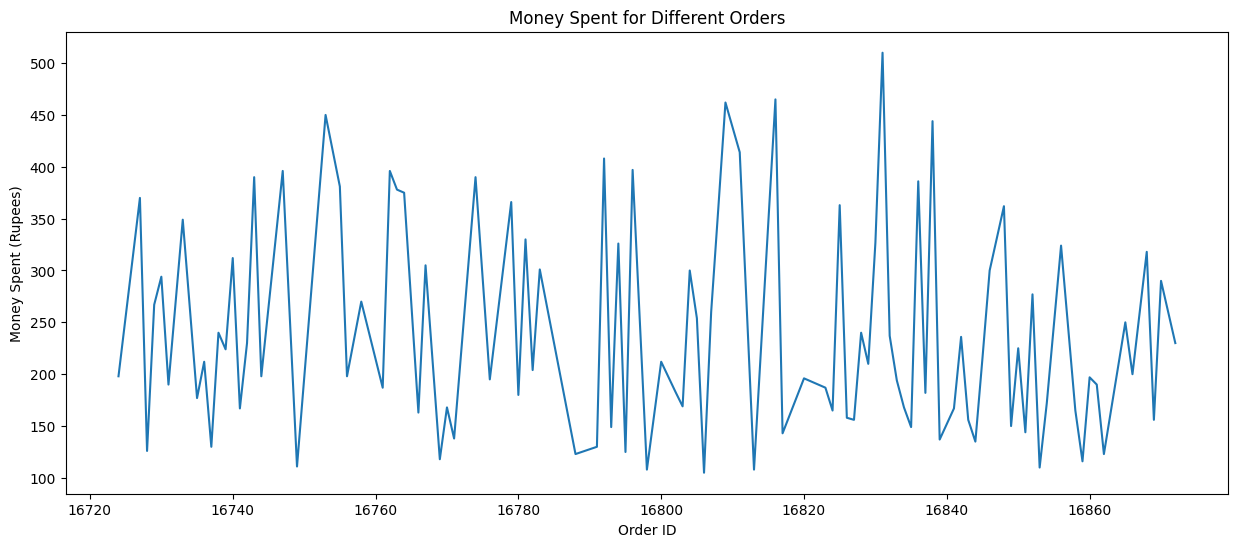

In [51]:
money_spent = df_new.groupby(by=['Order Id'], as_index=False)['money_spent'].sum()

plt.subplots(figsize=(15,6))

plt.plot(money_spent['Order Id'], money_spent['money_spent'])

plt.xlabel('Order ID')
plt.ylabel('Money Spent (Rupees)')
plt.title('Money Spent for Different Orders')

plt.show()

total quantity sold for each Order ID

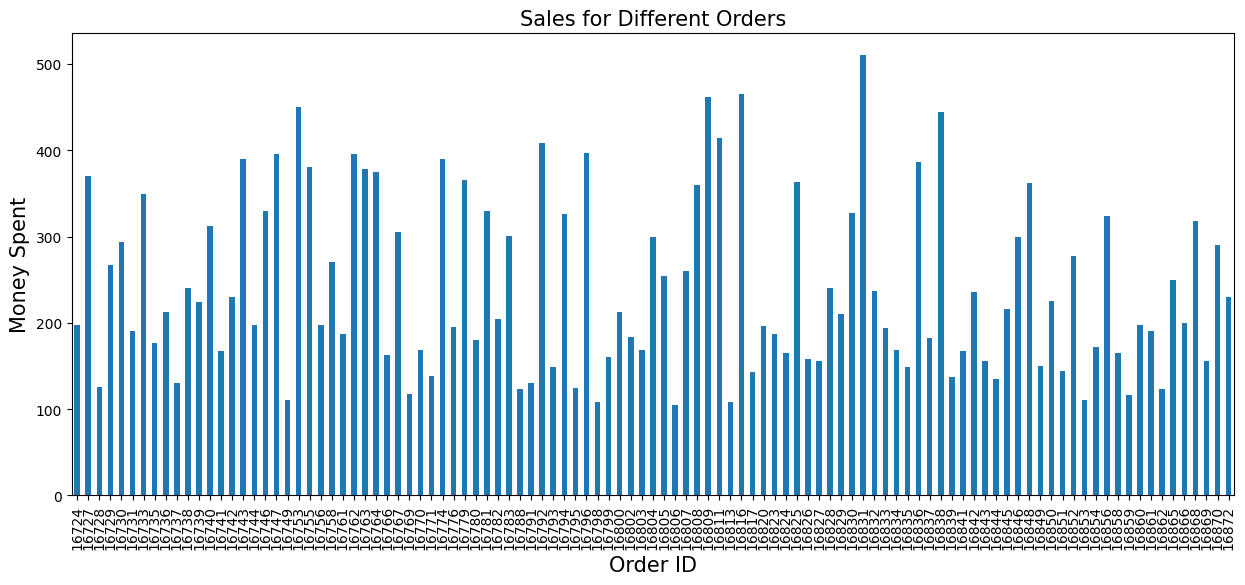

In [53]:
ax = df_new.groupby('Order Id')['money_spent'].sum().plot(
    kind='bar',
    figsize=(15,6)
)

ax.set_xlabel('Order ID', fontsize=15)
ax.set_ylabel('Money Spent', fontsize=15)
ax.set_title('Sales for Different Orders', fontsize=15)

plt.show()

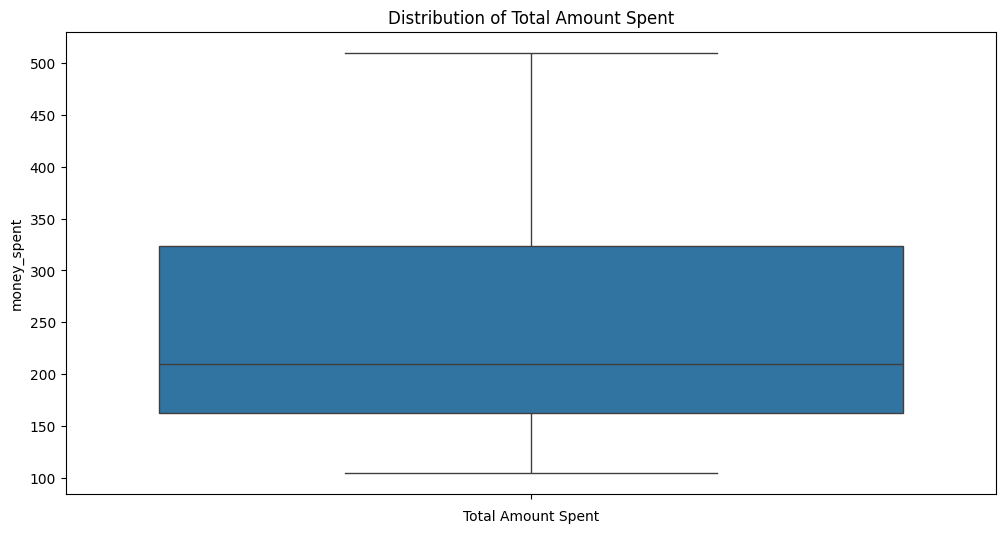

In [54]:
plt.subplots(figsize=(12,6))

sns.boxplot(df_new['money_spent'])

plt.xlabel('Total Amount Spent')
plt.title('Distribution of Total Amount Spent')

plt.show()

In [55]:
df_new.head()

,Order Id,Apples,Oranges,Bananas,Total_Quantity,money_spent
1,16724,12.0,12.0,6.0,30.0,198.0
4,16727,30.0,8.0,10.0,48.0,370.0
5,16728,6.0,6.0,12.0,24.0,126.0
6,16729,12.0,24.0,9.0,45.0,267.0
7,16730,24.0,6.0,8.0,38.0,294.0


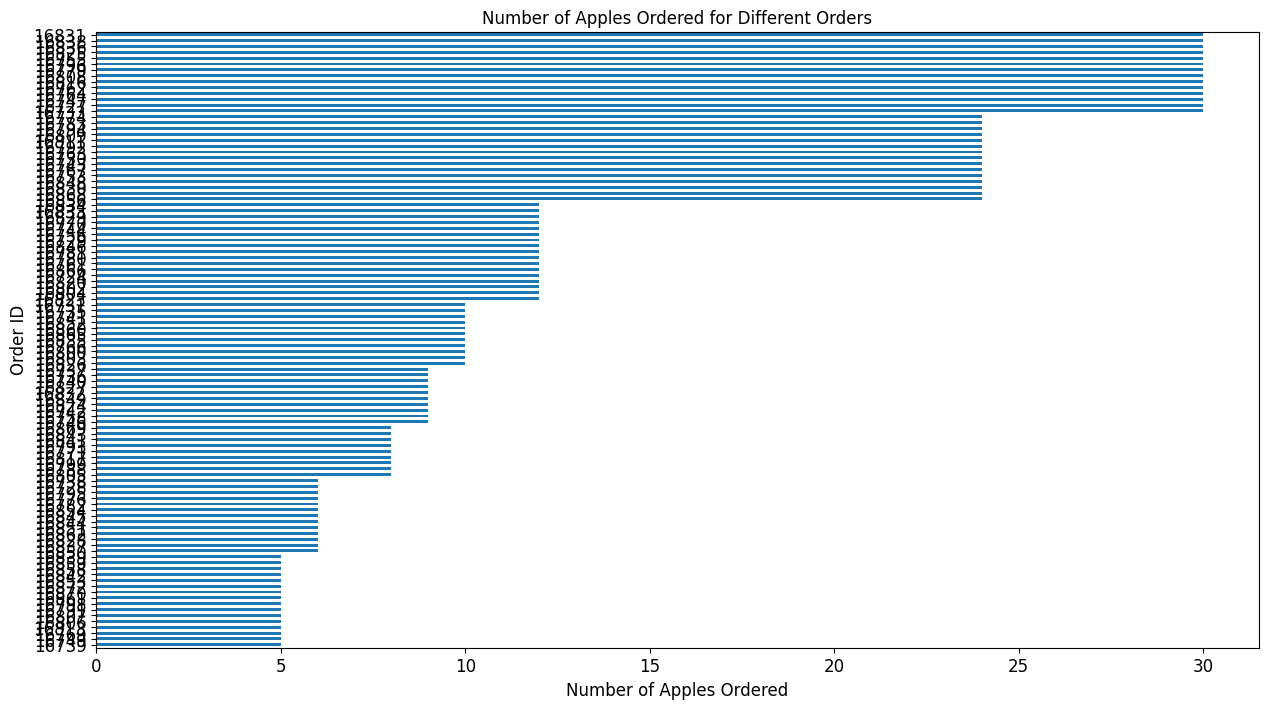

In [57]:
group_apple_orders = df_new.groupby('Order Id')['Apples'].sum().sort_values()

plt.subplots(figsize=(15,8))

group_apple_orders.plot(kind='barh', fontsize=12)

plt.xlabel('Number of Apples Ordered', fontsize=12)
plt.ylabel('Order ID', fontsize=12)
plt.title('Number of Apples Ordered for Different Orders', fontsize=12)

plt.show()

Pie chart for one order id

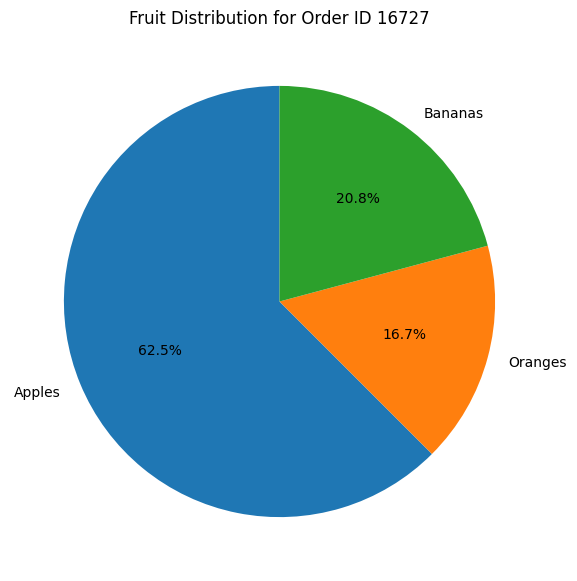

In [59]:
order_id = 16727

order = df_new[df_new['Order Id'] == order_id].iloc[0]

fruits = ['Apples', 'Oranges', 'Bananas']
quantities = [order['Apples'], order['Oranges'], order['Bananas']]

plt.figure(figsize=(7,7))
plt.pie(quantities, labels=fruits, autopct='%1.1f%%', startangle=90)
plt.title(f'Fruit Distribution for Order ID {order_id}')
plt.show()